# Case Study: Galaxy Velocities

This notebook demonstrates HAL density estimation, variance estimation, and targeting on real galaxy velocity data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import pathlib
import json
import os

root = pathlib.Path('.').resolve().parent
sys.path.append(str(root))

np.random.seed(42)

# Estimation
from src.haldensity.estimation import CVXPYEstimator
from src.haldensity.estimation.base_estimator import BaseEstimator

# Cross-validation
from src.haldensity.cross_validation.optuna_hyperparam_selector import OptunaHyperparameterTuner

# Variance estimation
from src.haldensity.density_variance.density_variance import (
    estimate_covariance_beta, 
    density_confidence_interval
)

# Targeting
from src.haldensity.targeting import (
    SurvivalTargetLearner,
    MomentsTargetLearner,
    MedianTargetLearner,
)

# Utility functions
from src.haldensity.utils.density_computations import (
    generic_compute_survival_from_density,
    generic_compute_moment_from_density,
    generic_compute_median_from_density,
)

## Load Data

(0.0, 1.0)

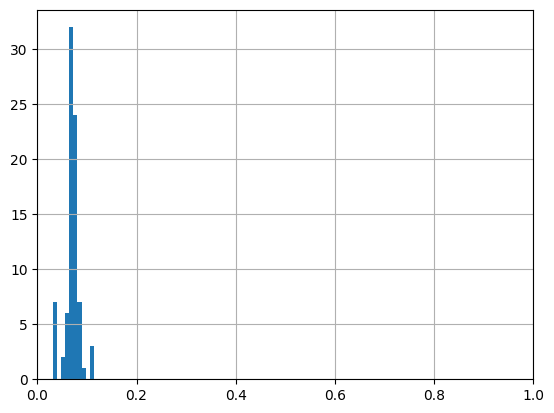

In [2]:
df = pd.read_csv("case_study/galaxies.csv")

(df["velocity"] / 3e5).hist()
plt.xlim(0., 1)

### Normalize by Speed of Light

In [3]:
# Normalize such that in relation to speed of light (3e5 km/s)
df_norm = df.copy()
df_norm["velocity"] = df_norm["velocity"] / 3e5
df_norm.head()

,id,velocity
0,1,0.030573
1,2,0.031167
2,3,0.031610
3,4,0.031860
4,5,0.032583


## Density Fit

Optimizing CVXPYEstimator: 100%|██████████| 100/100 [01:01<00:00,  1.62trial/s, Best SLL: 3.0956]


Best params: {'basis_order': 2, 'norm_constraint': 766252.6799757631}
Best CV: 3.0956015544954734


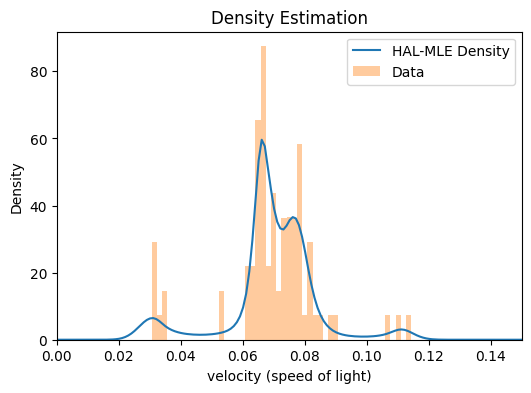

In [4]:
# Cross-validation with Optuna to select CVXPYEstimator hyperparameters
data = pd.DataFrame({'W1': df_norm['velocity']})

tuner = OptunaHyperparameterTuner(
    'CVXPYEstimator', 
    data, 
    cv_folds=5, 
    metric='sll', 
    silent=True, 
    show_progress=True, 
    param_overrides={"basis_order": [0, 2]}
)
res = tuner.optimize(n_trials=100, show_progress=False)
print('Best params:', res['best_params'])
print('Best CV:', res['best_metric_value'])

# Fit best model
best_est: CVXPYEstimator = tuner.fit_best_model()

# Get results and extract basis order
estimation_results = best_est.get_results()
basis_order = getattr(best_est, 'basis_order', 0)

# Evaluate density on fine grid for plotting
fine_grid = np.linspace(0, 1, 1000)
fine_grid_density = best_est.get_density_at_points(fine_grid)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(fine_grid, fine_grid_density, label='HAL-MLE Density')
plt.hist(data.W1, bins=50, density=True, alpha=0.4, label='Data')
plt.legend()
plt.xlim((0, 0.15))
plt.xlabel('velocity (speed of light)')
plt.ylabel('Density')
plt.title('Density Estimation')
plt.show()

## Density Variance

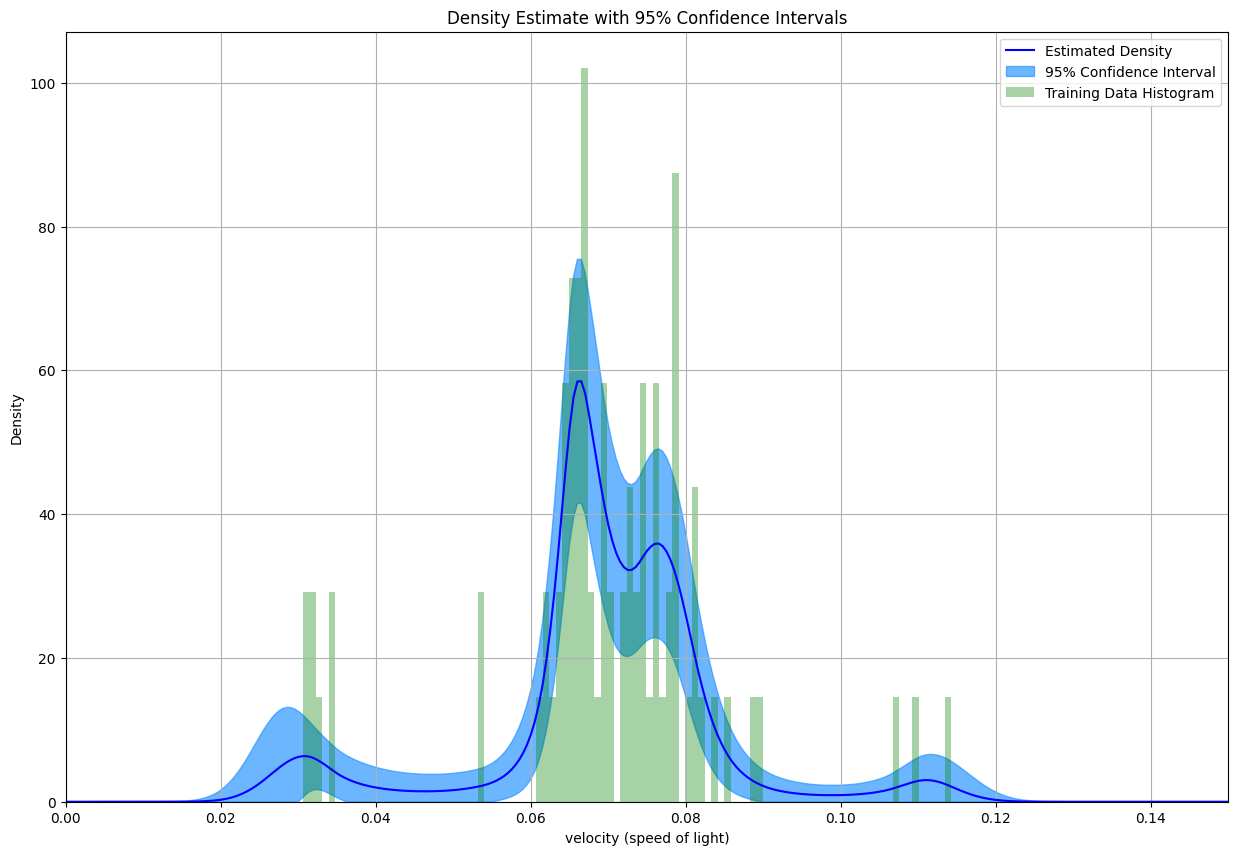

In [5]:
# Compute sandwich covariance component and confidence intervals
cov_beta = estimate_covariance_beta(data, estimation_results, basis_order, 1e-10)
x_vals = np.linspace(0, 1, 2000)
ci_df = density_confidence_interval(x_vals, estimation_results, cov_beta, basis_order=basis_order, alpha=0.05)

# Plot the results
plt.figure(figsize=(15, 10))
plt.plot(ci_df['x'], ci_df['density'], label='Estimated Density', color='blue')
plt.fill_between(ci_df['x'], ci_df['lower'], ci_df['upper'], color='dodgerblue', alpha=0.65,
                 label='95% Confidence Interval')
plt.hist(data['W1'], bins=100, density=True, alpha=0.35, label='Training Data Histogram', color='green')
plt.xlim((0, 0.15))
plt.legend()
plt.xlabel('velocity (speed of light)')
plt.ylabel('Density')
plt.title('Density Estimate with 95% Confidence Intervals')
plt.grid()
plt.show()

In [6]:
# BOOTSTRAP THIS TO COMPARE DENSITY VARIANCE - USING N_JOB = 32 TO PARALLELIZE
from joblib import Parallel, delayed
from scipy.interpolate import interp1d
import warnings
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

# Bootstrap: pointwise density band (no variance computation inside the loop)
B = 1000
N_JOB = 32
RE_TUNE = True       # set True to re-run Optuna per bootstrap sample (slower)
N_TRIALS_BOOT = 100    # only used if RE_TUNE=True

# Common x-grid: align with the Delta-method CI if available
x_grid = ci_df['x'].to_numpy() if 'ci_df' in globals() else np.linspace(0, 1, 600)

def fit_density_on_bootstrap(rep_idx: int):
    rng = np.random.default_rng(2025 + rep_idx)
    boot_idx = rng.integers(0, len(data), size=len(data))
    data_boot = data.iloc[boot_idx].reset_index(drop=True)
    try:
        tuner_b = OptunaHyperparameterTuner('CVXPYEstimator', data_boot,
                                            cv_folds=5, metric='sll', silent=True, show_progress=False)
        tuner_b.optimize(n_trials=N_TRIALS_BOOT, show_progress=False)
        est_b = tuner_b.fit_best_model()
        g_b, d_b = est_b.get_density()
        f_b = interp1d(g_b, d_b, bounds_error=False, fill_value=0.0)
        return f_b(x_grid)
    except Exception:
        return None

# Load results from case_study/bootstrap_results.json
with open("case_study/bootstrap_results.json", "r") as f:
    boot_results = json.load(f)
x_grid = np.array(boot_results['x_grid'])
dens_stack = np.array(boot_results['dens_stack'])
B = boot_results['B']
N_JOB = boot_results['N_JOB']
RE_TUNE = boot_results['RE_TUNE']
N_TRIALS_BOOT = boot_results['N_TRIALS_BOOT']

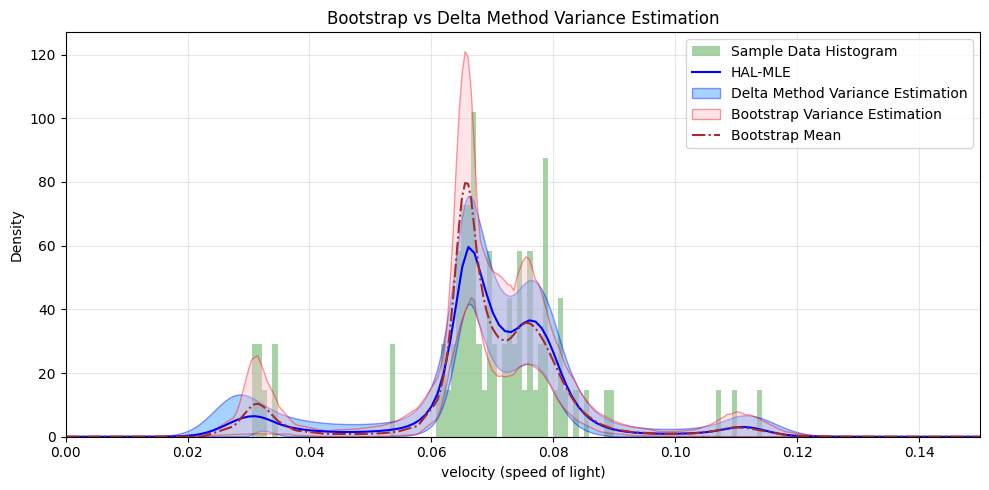

In [7]:
boot_mean = dens_stack.mean(axis=0)
boot_lo = np.quantile(dens_stack, 0.025, axis=0)
boot_hi = np.quantile(dens_stack, 0.975, axis=0)

# Plot: histogram + original estimate + Delta CI + Bootstrap band
plt.figure(figsize=(10, 5))
plt.hist(data['W1'], bins=100, density=True, alpha=0.35, label='Sample Data Histogram', color='green')
plt.plot(fine_grid, fine_grid_density, color='blue', lw=1.5, label='HAL-MLE')
plt.fill_between(ci_df['x'], ci_df['lower'], ci_df['upper'], color='dodgerblue', alpha=0.4, 
                 label='Delta Method Variance Estimation', edgecolor='blue')
plt.fill_between(x_grid, boot_lo, boot_hi, color='pink', alpha=0.4, 
                 label='Bootstrap Variance Estimation', edgecolor='red')
plt.plot(x_grid, boot_mean, color='brown', lw=1.5, label='Bootstrap Mean', linestyle='-.')
plt.xlim((0, 0.15))
plt.xlabel('velocity (speed of light)')
plt.ylabel('Density')
plt.title(f'Bootstrap vs Delta Method Variance Estimation')
plt.grid(True, alpha=0.3)
plt.legend()    
plt.tight_layout()
plt.show()

## Targeting

### Target Survival Function

In [8]:
# Define targeting points
targeting_points = np.linspace(0.00, 0.15, 10)

# Create survival target learner
survival_learner = SurvivalTargetLearner(norm_constraint=100, basis_order=basis_order)

# Run M-step for survival targeting
targeted_fit_survival = survival_learner.run_m_step(
    uncensored_augmented=data,
    grid_points_hal_selected=estimation_results['grid_points_hal_selected'],
    old_theta=np.array(estimation_results['theta_hat']),
    _old_theta=np.array(estimation_results['theta_hat']),
    _grid_points_hal_selected=estimation_results['grid_points_hal_selected'],
    targeting_points=targeting_points,
)

Survival variances: [0.         0.         0.00070688 0.00096393 0.00290281 0.00083724
 0.00043515 0.         0.         0.        ]


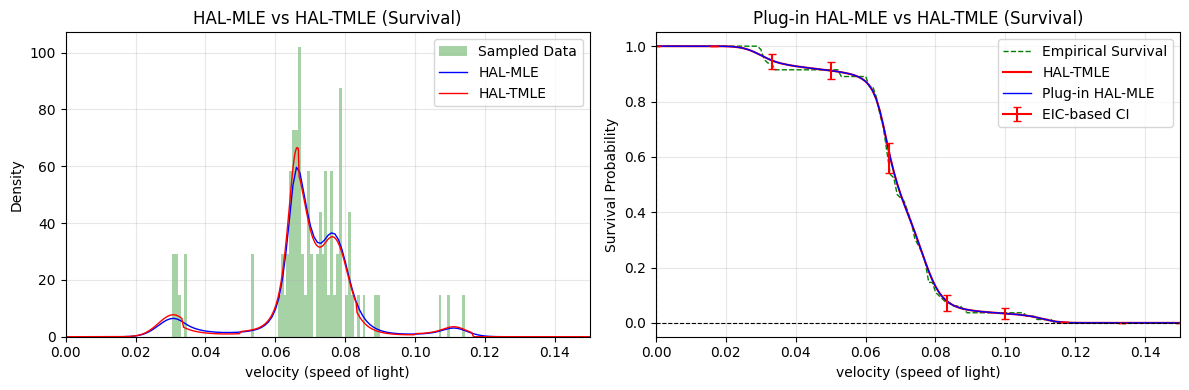

In [9]:
# Compute survival functions from different approaches
# 1. Targeted survival function
stats_targeted, grid_points_survival = generic_compute_survival_from_density(
    grid_points=fine_grid,
    density=fine_grid_density,
)

# 2. Empirical survival function from data
bin_edges = np.concatenate([fine_grid, [fine_grid[-1] + (fine_grid[-1] - fine_grid[-2])]])
density_at_grid, _ = np.histogram(data.W1, bins=bin_edges, density=True)
stats_empirical, _ = generic_compute_survival_from_density(
    grid_points=fine_grid,
    density=density_at_grid
)

# 3. Plug-in HAL-MLE survival function
raw_density_est = BaseEstimator.calculate_density_at_points(
    points=fine_grid,
    theta_hat=np.array(estimation_results['theta_hat']),
    basis_grid_points=estimation_results['grid_points_hal_selected'],
    basis_order=basis_order
)
stats_raw, _ = generic_compute_survival_from_density(
    grid_points=fine_grid,
    density=raw_density_est
)

# Estimate variances for targeting points
variances = survival_learner.get_estimand_variance(
    targeted_fit=targeted_fit_survival,
    uncensored_data=data,
    targeting_points=targeting_points,
)
print("Survival variances:", variances)

# Get standard errors for confidence intervals
standard_errors = np.sqrt(variances)

# Plot combined figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: HAL-MLE vs HAL-TMLE (Survival) density
ax1.hist(
    data["W1"], 
    bins=100, 
    density=True, 
    alpha=0.35, 
    label="Sampled Data",
    color='green'
)
ax1.plot(
    fine_grid, 
    fine_grid_density, 
    label="HAL-MLE",
    color='blue',
    linestyle='-',
    linewidth=1
)
ax1.plot(
    targeted_fit_survival['grid_midpoints'],
    targeted_fit_survival['estimated_density'],
    label="HAL-TMLE",
    color='red',
    linestyle='-',
    linewidth=1
)
ax1.set_xlim((0, 0.15))
ax1.set_xlabel('velocity (speed of light)')
ax1.set_ylabel('Density')
ax1.set_title('HAL-MLE vs HAL-TMLE (Survival)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Plug-in HAL-MLE vs HAL-TMLE (Survival)
ax2.plot(grid_points_survival, stats_empirical, label='Empirical Survival', color='green', linestyle='--', linewidth=1)
ax2.plot(grid_points_survival, stats_targeted, label='HAL-TMLE', color='red', linewidth=1.5)
ax2.plot(grid_points_survival, stats_raw, label='Plug-in HAL-MLE', color='blue', linestyle='-', linewidth=1)
for i, point in enumerate(targeting_points):
    stat_idx = np.searchsorted(grid_points_survival, point)
    stat_i = stats_targeted[stat_idx]
    ax2.errorbar(
        point, 
        stat_i, 
        yerr=standard_errors[i], 
        color='red', 
        label='EIC-based CI' if i == 0 else "",
        capsize=3
    )
ax2.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title('Plug-in HAL-MLE vs HAL-TMLE (Survival)')
ax2.set_xlim((0, 0.15))
ax2.set_xlabel('velocity (speed of light)')
ax2.set_ylabel('Survival Probability')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

### Target Mean

In [10]:
# Target the mean (first moment, k=1)
moment_order = 1

# Create moments target learner
moments_learner = MomentsTargetLearner(norm_constraint=100, basis_order=basis_order)

# Run M-step for mean targeting
targeted_fit_mean = moments_learner.run_m_step(
    uncensored_augmented=data,
    grid_points_hal_selected=estimation_results['grid_points_hal_selected'],
    old_theta=np.array(estimation_results['theta_hat']),
    _old_theta=np.array(estimation_results['theta_hat']),
    _grid_points_hal_selected=estimation_results['grid_points_hal_selected'],
    x_moment=1,
)

print("Mean targeting results keys:", targeted_fit_mean.keys())

Mean targeting results keys: dict_keys(['old_theta', 'theta_targeting', 'theta_intercept', 'theta_selected', 'estimated_density', 'grid_midpoints', 'grid_points_hal_selected', 'b_jk', 'b_jk_targeting', 'delta_j', 'grid_eval'])


In [11]:
# Compute mean estimates from different approaches
# 1. Mean from targeted density
mean_targeted = generic_compute_moment_from_density(
    grid_points=targeted_fit_mean['grid_midpoints'],
    density=targeted_fit_mean['estimated_density'],
    moment_order=1
)

# 2. Empirical mean from data
mean_empirical = np.mean(data['W1'])

# 3. Mean from original (non-targeted) density  
mean_original = generic_compute_moment_from_density(
    grid_points=fine_grid,
    density=fine_grid_density,
    moment_order=1
)

print(f"Empirical mean: {mean_empirical:.6f}")
print(f"Original density mean: {mean_original:.6f}")
print(f"Targeted density mean: {mean_targeted:.6f}")

# Estimate variance of mean using EIC
variance_mean = moments_learner.get_estimand_variance(
    targeted_fit=targeted_fit_mean,
    uncensored_data=data,
    x_moment=1,
)

standard_error_mean = np.sqrt(variance_mean[0])
print(f"Mean standard error: {standard_error_mean:.6f}")

# 95% confidence interval for mean
ci_lower = mean_targeted - 1.96 * standard_error_mean
ci_upper = mean_targeted + 1.96 * standard_error_mean
print(f"95% CI for mean: [{ci_lower:.6f}, {ci_upper:.6f}]")

Empirical mean: 0.069427
Original density mean: 0.069775
Targeted density mean: 0.069414
Mean standard error: 0.001680
95% CI for mean: [0.066121, 0.072706]


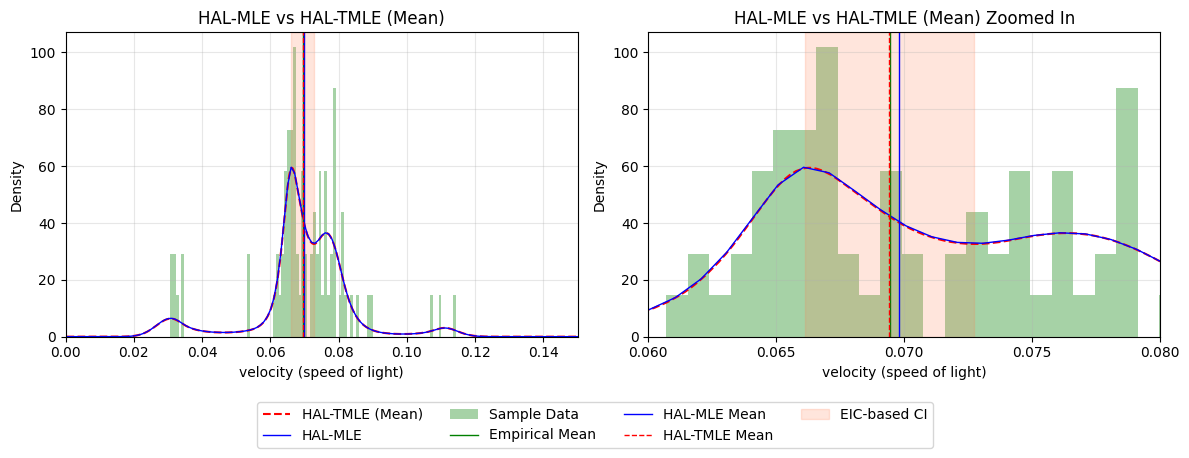

In [12]:
# Visualization of mean estimates with confidence interval
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: full view
ax1.plot(targeted_fit_mean['grid_midpoints'], targeted_fit_mean['estimated_density'], 
         label='HAL-TMLE (Mean)', color='red', linewidth=1.5, linestyle='--')
ax1.plot(fine_grid, fine_grid_density, label='HAL-MLE', color='blue', linestyle='-', linewidth=1)
ax1.hist(data["W1"], bins=100, density=True, alpha=0.35, 
         label="Sample Data", color='green')

ax1.axvline(mean_empirical, color='green', linestyle='-', linewidth=1, 
           label='Empirical Mean')
ax1.axvline(mean_original, color='blue', linestyle='-', linewidth=1, 
           label='HAL-MLE Mean')
ax1.axvline(mean_targeted, color='red', linestyle='--', linewidth=1, 
           label='HAL-TMLE Mean')

ax1.axvspan(ci_lower, ci_upper, alpha=0.2, color='coral', 
           label='EIC-based CI')

ax1.set_xlim((0, 0.15))
ax1.set_xlabel('velocity (speed of light)')
ax1.set_ylabel('Density')
ax1.set_title('HAL-MLE vs HAL-TMLE (Mean)')
ax1.grid(True, alpha=0.3)

# Right: zoomed view
ax2.plot(targeted_fit_mean['grid_midpoints'], targeted_fit_mean['estimated_density'], 
         color='red', linewidth=1.5, linestyle='--')
ax2.plot(fine_grid, fine_grid_density, color='blue', linestyle='-', linewidth=1)
ax2.hist(data["W1"], bins=100, density=True, alpha=0.35, 
         color='green')

ax2.axvline(mean_empirical, color='green', linestyle='-', linewidth=1)
ax2.axvline(mean_original, color='blue', linestyle='-', linewidth=1)
ax2.axvline(mean_targeted, color='red', linestyle='--', linewidth=1)

ax2.axvspan(ci_lower, ci_upper, alpha=0.2, color='coral')

ax2.set_xlim((0.06, 0.08))
ax2.set_xticks([0.06, 0.065, 0.07, 0.075, 0.08])
ax2.set_xlabel('velocity (speed of light)')
ax2.set_ylabel('Density')
ax2.set_title('HAL-MLE vs HAL-TMLE (Mean) Zoomed In')
ax2.grid(True, alpha=0.3)

# Add legend below the figure in 4 columns
fig.legend(labels=['HAL-TMLE (Mean)', 'HAL-MLE', 'Sample Data', 'Empirical Mean', 
                   'HAL-MLE Mean', 'HAL-TMLE Mean', 'EIC-based CI'],
           loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.tight_layout()
plt.show()

### Target Median

In [13]:
# Target the median
median_learner = MedianTargetLearner(norm_constraint=100, basis_order=basis_order)

# Run M-step for median targeting
targeted_fit_median = median_learner.run_m_step(
    uncensored_augmented=data,
    grid_points_hal_selected=estimation_results['grid_points_hal_selected'],
    old_theta=np.array(estimation_results['theta_hat']),
    _old_theta=np.array(estimation_results['theta_hat']),
    _grid_points_hal_selected=estimation_results['grid_points_hal_selected'],
)

print("Median targeting results keys:", targeted_fit_median.keys())

Median targeting results keys: dict_keys(['old_theta', 'theta_targeting', 'theta_intercept', 'theta_selected', 'estimated_density', 'grid_midpoints', 'grid_points_hal_selected', 'b_jk', 'b_jk_targeting', 'delta_j', 'grid_eval'])


In [14]:
# Compute median estimates from different approaches
# 1. Median from targeted density
median_targeted, density_at_median_targeted = generic_compute_median_from_density(
    grid_points=targeted_fit_median['grid_midpoints'],
    density=targeted_fit_median['estimated_density']
)

# 2. Empirical median from data
median_empirical = np.median(data['W1'])

# 3. Median from original (non-targeted) density
median_original, density_at_median_original = generic_compute_median_from_density(
    grid_points=fine_grid,
    density=fine_grid_density
)

print(f"Empirical median: {median_empirical:.6f}")
print(f"Original density median: {median_original:.6f}")
print(f"Targeted density median: {median_targeted:.6f}")

# Estimate variance of median using EIC
variance_median = median_learner.get_estimand_variance(
    targeted_fit=targeted_fit_median,
    uncensored_data=data,
)

standard_error_median = np.sqrt(variance_median[0])
print(f"Median standard error: {standard_error_median:.6f}")

# 95% confidence interval for median
ci_lower_median = median_targeted - 1.96 * standard_error_median
ci_upper_median = median_targeted + 1.96 * standard_error_median
print(f"95% CI for median: [{ci_lower_median:.6f}, {ci_upper_median:.6f}]")

Empirical median: 0.069445
Original density median: 0.069069
Targeted density median: 0.069158
Median standard error: 0.001222
95% CI for median: [0.066763, 0.071554]


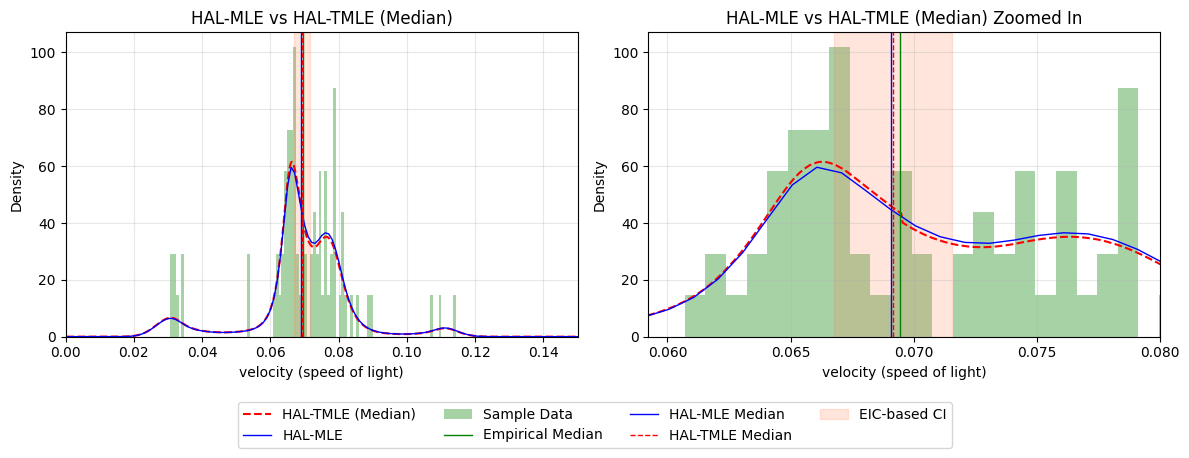

In [15]:
# Visualization of median estimates with confidence interval
median_center = (median_empirical + median_original + median_targeted) / 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: full view
ax1.plot(targeted_fit_median['grid_midpoints'], targeted_fit_median['estimated_density'], 
         label='HAL-TMLE (Median)', color='red', linewidth=1.5, linestyle='--')
ax1.plot(fine_grid, fine_grid_density, label='HAL-MLE', color='blue', linestyle='-', linewidth=1)
ax1.hist(data["W1"], bins=100, density=True, alpha=0.35, 
         label="Sample Data", color='green')

ax1.axvline(median_empirical, color='green', linestyle='-', linewidth=1, 
           label='Empirical Median')
ax1.axvline(median_original, color='blue', linestyle='-', linewidth=1, 
           label='HAL-MLE Median')
ax1.axvline(median_targeted, color='red', linestyle='--', linewidth=1, 
           label='HAL-TMLE Median')

ax1.axvspan(ci_lower_median, ci_upper_median, alpha=0.2, color='coral', 
           label='EIC-based CI')

ax1.set_xlim((0, 0.15))
ax1.set_xlabel('velocity (speed of light)')
ax1.set_ylabel('Density')
ax1.set_title('HAL-MLE vs HAL-TMLE (Median)')
ax1.grid(True, alpha=0.3)

# Right: zoomed view
ax2.plot(targeted_fit_median['grid_midpoints'], targeted_fit_median['estimated_density'], 
         color='red', linewidth=1.5, linestyle='--')
ax2.plot(fine_grid, fine_grid_density, color='blue', linestyle='-', linewidth=1)
ax2.hist(data["W1"], bins=100, density=True, alpha=0.35, 
         color='green')

ax2.axvline(median_empirical, color='green', linestyle='-', linewidth=1)
ax2.axvline(median_original, color='blue', linestyle='-', linewidth=1)
ax2.axvline(median_targeted, color='red', linestyle='--', linewidth=1)

ax2.axvspan(ci_lower_median, ci_upper_median, alpha=0.2, color='coral')

ax2.set_xlim((median_center - 0.01, median_center + 0.01))
ax2.set_xticks([0.06, 0.065, 0.07, 0.075, 0.08])
ax2.set_xlabel('velocity (speed of light)')
ax2.set_ylabel('Density')
ax2.set_title('HAL-MLE vs HAL-TMLE (Median) Zoomed In')
ax2.grid(True, alpha=0.3)

# Add legend below the figure in 4 columns
fig.legend(['HAL-TMLE (Median)', 'HAL-MLE', 'Sample Data', 'Empirical Median', 
           'HAL-MLE Median', 'HAL-TMLE Median', 'EIC-based CI'], 
          loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=4)

plt.tight_layout()
plt.show()